# EDA — EHF 2024 Masculino (v2)

**Propósito:** Análisis Exploratorio de Datos del conjunto de jugadores de campo del EHF 2024.  
**Input:** `EHF2024-M-AGGREGATED.csv`  
**Output:** Figuras para la memoria del TFM.

---
**Índice:**
1. Carga y configuración
2. Descripción general
3. Distribución por posición
4. Estadísticos descriptivos globales (estilo stats_bars)
5. Estadísticos descriptivos por posición (estilo stats_bars)
6. Análisis de correlación
7. Distribución de ceros y asimetría
8. Detección de outliers
9. Histogramas individuales
10. Violin plots por posición

---
## 1. Carga y configuración

In [335]:
import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# ── Estilo global ────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)

POS_COLORS = {
    'CB': '#3266ad', 'LB': '#d85a30', 'LP': '#1d9e75',
    'LW': '#7f77dd', 'RB': '#888780', 'RW': '#ba7517'
}
POS_NAMES = {
    'CB': 'Central', 'LB': 'Lat. Izq.', 'LP': 'Pivote',
    'LW': 'Ext. Izq.', 'RB': 'Lat. Der.', 'RW': 'Ext. Der.'
}
GLOBAL_COLOR = '#3266ad'

CSV_PATH = 'EHF2024-M-AGGREGATED.csv'
COLS_DROP = ['Team','No','Name','Position','scoring','topk','top1',
             'Unnamed: 0','R7','P7']

os.makedirs('eda_output', exist_ok=True)
print('Configuración cargada.')

Configuración cargada.


In [336]:
df_raw  = pd.read_csv(CSV_PATH)
#df      = df_raw[df_raw['Position'] != 'GK'].reset_index(drop=True)
df  = pd.read_csv(CSV_PATH)
NUM_COLS = [c for c in df.columns if c not in COLS_DROP]
X        = df[NUM_COLS].copy()

print(f'Dataset original : {df_raw.shape[0]} jugadores, {df_raw.shape[1]} columnas')
print(f'Sin porteros     : {df.shape[0]} jugadores')
print(f'Variables clustering ({len(NUM_COLS)}): {NUM_COLS}')

Dataset original : 427 jugadores, 32 columnas
Sin porteros     : 427 jugadores
Variables clustering (22): ['7mPGoals', '7mPMissed', '6mCGoals', '6mCMissed', 'WingGoals', 'WingMissed', 'BTGoals', 'BTMissed', 'FBGoals', 'FBMissed', 'FTOGoals', 'FTOMissed', '9mGoals', '9mMissed', 'RC', '2M', '2+2', 'AS', 'ST', 'BS', 'TO', 'Time']


---
## 2. Descripción general

In [337]:
print(f'Filas: {df.shape[0]}  |  Variables clustering: {len(NUM_COLS)}')
nulls = X.isnull().sum()
if nulls.sum() == 0:
    print('No hay valores nulos en las variables de clustering.')
else:
    print(nulls[nulls > 0])

Filas: 427  |  Variables clustering: 22
No hay valores nulos en las variables de clustering.


---
## 3. Distribución por posición

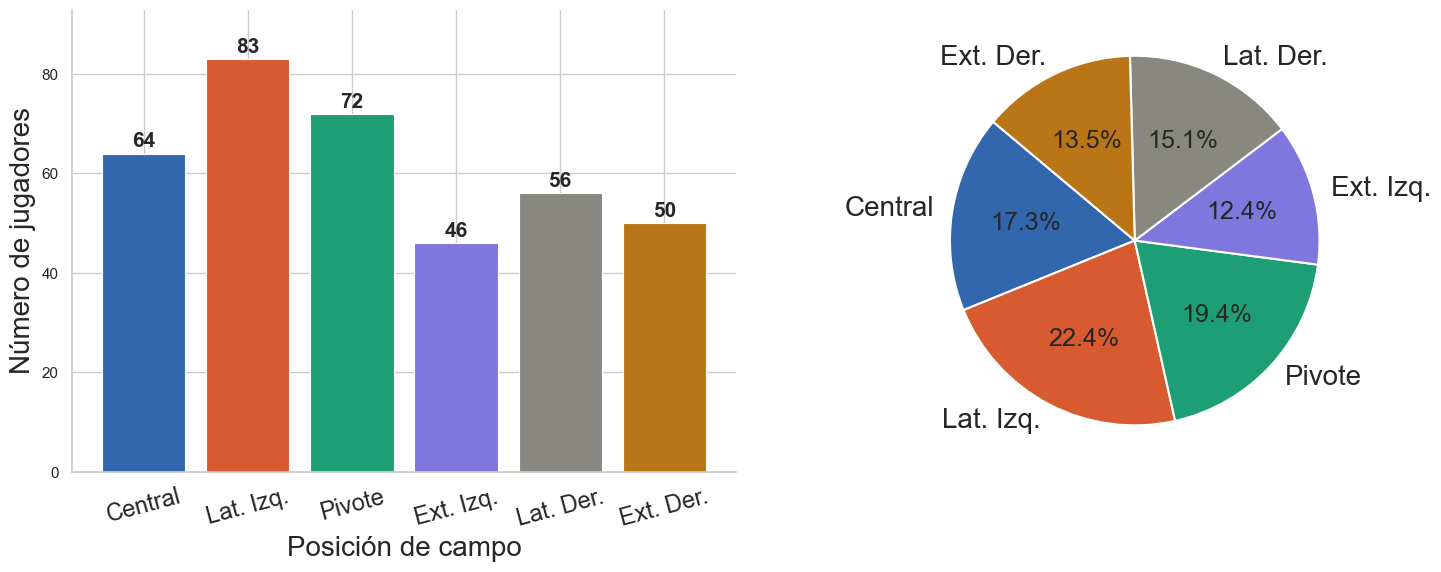

Guardado: eda_output/eda_01_distribucion_posicion.png


In [338]:
pos_order  = list(POS_NAMES.keys())
pos_counts = df['Position'].value_counts().reindex(pos_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')
fig.subplots_adjust(wspace=0.10)

ax = axes[0]
bars = ax.bar([POS_NAMES[p] for p in pos_order],
              pos_counts.values,
              color=[POS_COLORS[p] for p in pos_order],
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, pos_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=15, fontweight='bold')
ax.set_xlabel('Posición de campo', fontsize=20)
ax.set_ylabel('Número de jugadores', fontsize=20)
ax.tick_params(axis='x', rotation=15, labelsize=17)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(0, pos_counts.max() * 1.12)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    pos_counts.values,
    labels=[POS_NAMES[p] for p in pos_order],
    colors=[POS_COLORS[p] for p in pos_order],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=20))
for at in autotexts: at.set_fontsize(18)

plt.savefig('eda_output/eda_01_distribucion_posicion.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_01_distribucion_posicion.png')


---
## 4. Estadísticos descriptivos globales (estilo stats_bars)

Para cada variable se muestra: media (barra principal), desviación estándar (barras de error),
rango [min–max] (fondo traslúcido) y mediana (punto blanco).

In [339]:
def plot_stats_bars(stats_df, label, out_path, color='#3266ad',
                    vars_per_page=19, n_cols=4, fig_w=32):
    rows       = stats_df.index.tolist()
    variables  = stats_df.columns.get_level_values(0).unique().tolist()
    n_vars     = len(variables)
    n_var_rows = math.ceil(n_vars / n_cols)
    saved = []
    ROWS_PER_PAGE = 10
    pages = [rows[i:i+ROWS_PER_PAGE] for i in range(0, len(rows), ROWS_PER_PAGE)]

    for page_num, page_rows in enumerate(pages):
        n_r = len(page_rows)
        # Alto generoso: 8in por fila para que cada subgráfico se vea en LaTeX
        fig = plt.figure(figsize=(fig_w, 8.0 * n_r), facecolor='#f8f8f6')
        fig.subplots_adjust(hspace=0.0, top=0.99, bottom=0.01,
                            left=0.02, right=0.98)
        outer = gridspec.GridSpec(n_r, 1, figure=fig, hspace=0.06)

        for ri, row_id in enumerate(page_rows):
            row_data   = stats_df.loc[row_id]
            c          = POS_COLORS.get(str(row_id), color)
            label_text = POS_NAMES.get(str(row_id), str(row_id))

            inner = gridspec.GridSpecFromSubplotSpec(
                n_var_rows + 1, n_cols,
                subplot_spec=outer[ri],
                hspace=0.33,
                wspace=0.14)

            # Cabecera
            ax_h = fig.add_subplot(inner[0, :])
            ax_h.set_facecolor(c + '15')
            ax_h.set_xlim(0,1); ax_h.set_ylim(0,1); ax_h.axis('off')
            ax_h.text(0.005, 0.5, str(row_id), fontsize=42, fontweight='bold',
                      color=c, va='center', ha='left',
                      transform=ax_h.transAxes, fontfamily='monospace')
            ax_h.text(0.09, 0.62, label_text, fontsize=22, fontweight='bold',
                      color='#333', va='center', ha='left', transform=ax_h.transAxes)
            ax_h.axhline(0.06, color=c, linewidth=3, xmin=0, xmax=1)

            for vi, var in enumerate(variables):
                row_idx = (vi // n_cols) + 1
                col_idx = vi % n_cols
                ax = fig.add_subplot(inner[row_idx, col_idx])
                ax.set_facecolor('white')

                mean_v   = max(float(row_data[(var, 'mean')]),   0)
                std_v    = max(float(row_data[(var, 'std')]),    0)
                min_v    = max(float(row_data[(var, 'min')]),    0)
                max_v    = max(float(row_data[(var, 'max')]),    0)
                median_v = max(float(row_data[(var, 'median')]), 0)

                ax.barh(0, max_v - min_v, left=min_v, height=0.50,
                        color=c, alpha=0.12, zorder=1)
                ax.barh(0, mean_v, height=0.50, color=c, alpha=0.85, zorder=2)
                ax.errorbar(mean_v, 0, xerr=std_v, fmt='none', color='#333',
                            linewidth=2, capsize=4, capthick=2, zorder=3)
                ax.scatter([median_v], [0], color='white', edgecolors=c,
                           linewidths=2, s=40, zorder=4)

                ax.text(0.98, 0.95, f'μ={mean_v:.2f}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=20, fontweight='bold', color='#222')
                ax.text(0.98, 0.65, f'±{std_v:.2f}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=20, color='#666')
                ax.text(0.02, 0.06, f'[{min_v:.1f}–{max_v:.1f}]',
                        transform=ax.transAxes, ha='left', va='bottom',
                        fontsize=20, color='#999')

                ax.set_title(var, fontsize=16, fontweight='bold',
                             color='#333', pad=3, loc='left')
                ax.set_yticks([])
                ax.tick_params(axis='x', labelsize=9, colors='#888')
                ax.spines[['top','right','left']].set_visible(False)
                ax.spines['bottom'].set_color('#ddd')
                ax.spines['bottom'].set_linewidth(0.6)
                ax.set_ylim(-0.45, 0.65)
                x_max = max(max_v * 1.12, mean_v + std_v * 1.4, 0.5)
                ax.set_xlim(0, x_max)

        legend_elements = [
            Patch(facecolor='gray', alpha=0.85, label='Media (μ)'),
            Line2D([0],[0], color='#333', linewidth=2,
                   label='Desv. estándar (±σ)'),
            Patch(facecolor='gray', alpha=0.12, label='Rango [min–max]'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                   markeredgecolor='gray', markersize=8, label='Mediana'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4,
                   fontsize=20, framealpha=0.9,
                   bbox_to_anchor=(0.5, 0.002), frameon=True)

        suffix = f'_p{page_num+1}' if len(pages) > 1 else ''
        base   = out_path.replace('.png', '')
        fpath  = f'{base}{suffix}.png'
        fig.savefig(fpath, dpi=180, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.close(fig)
        saved.append(fpath)
        print(f'  Guardado: {fpath}')

    return saved

print('Función plot_stats_bars definida.')


Función plot_stats_bars definida.


In [340]:
# ── Estadísticos globales (una sola fila: 'Global') ──────────
global_stats = X.agg(['mean','std','median','min','max']).T
global_stats.columns = pd.MultiIndex.from_product(
    [global_stats.columns, ['']]).droplevel(1)  # temporal

# Reconstruir como MultiIndex (var, stat) para compatibilidad con la función
records = {}
for stat in ['mean','std','median','min','max']:
    for var in NUM_COLS:
        records[(var, stat)] = X[var].agg(stat)

global_mi = pd.DataFrame([records], index=['Global'])
global_mi.columns = pd.MultiIndex.from_tuples(global_mi.columns)
global_mi = global_mi.clip(lower=0)

saved_global = plot_stats_bars(
    global_mi,
    label='EHF 2024 — Estadísticos descriptivos globales (N=371 jugadores de campo)',
    out_path='eda_output/eda_02_stats_global.png',
    color=GLOBAL_COLOR,
    n_cols=4
)

  Guardado: eda_output/eda_02_stats_global.png


---
## 5. Estadísticos descriptivos por posición (estilo stats_bars)

In [341]:
# ── Estadísticos por posición (una fila por posición) ────────
pos_stats = df.groupby('Position')[NUM_COLS].agg(
    ['mean','std','median','min','max']
).clip(lower=0)
# Reordenar por POS_NAMES
pos_stats = pos_stats.reindex(list(POS_NAMES.keys()))

saved_pos = plot_stats_bars(
    pos_stats,
    label='EHF 2024 — Estadísticos descriptivos por posición táctica',
    out_path='eda_output/eda_03_stats_posicion.png',
    color='#3266ad',   # se sobreescribirá por POS_COLORS dentro de la función
    n_cols=4
)
print(f'Total páginas generadas: {len(saved_pos)}')

  Guardado: eda_output/eda_03_stats_posicion.png
Total páginas generadas: 1


---
## 6. Análisis de correlación

In [342]:
corr = X.corr()

# Pares con |r| > 0.7
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i, j]
        if abs(v) > 0.7:
            pairs.append((corr.columns[i], corr.columns[j], round(v, 3)))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print('Pares con |r| > 0.7:')
for a, b, r in pairs:
    print(f'  {a:15s} — {b:15s}  r = {r}')

Pares con |r| > 0.7:
  9mGoals         — 9mMissed         r = 0.856
  AS              — TO               r = 0.845
  WingGoals       — WingMissed       r = 0.822
  BTGoals         — AS               r = 0.779
  BTGoals         — TO               r = 0.741
  6mCGoals        — 6mCMissed        r = 0.724
  9mMissed        — AS               r = 0.716
  7mPGoals        — 7mPMissed        r = 0.712


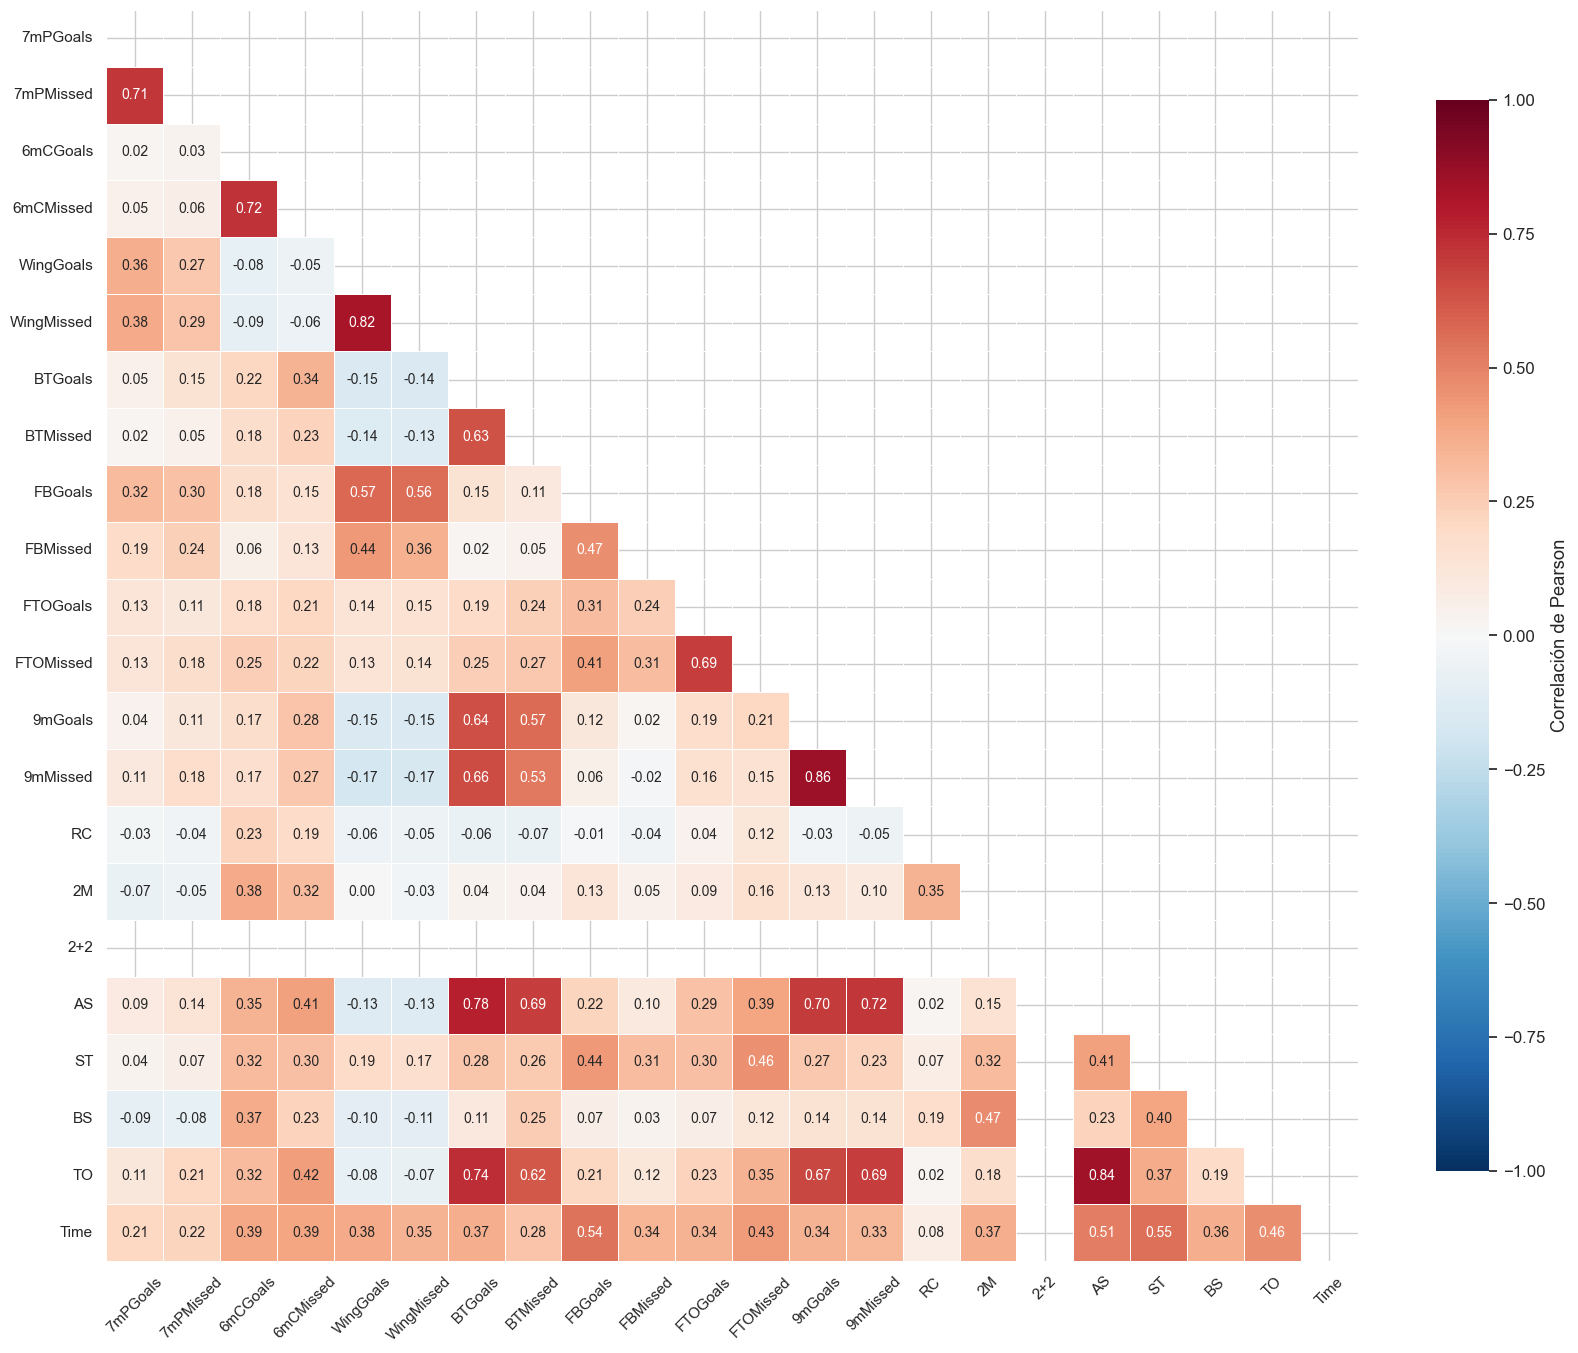

Guardado: eda_output/eda_04_correlacion.png


In [343]:
fig, ax = plt.subplots(figsize=(17, 15), facecolor='white')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, square=True, ax=ax,
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.75, 'label': 'Correlación de Pearson'})
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0,  labelsize=11)
plt.tight_layout()
plt.savefig('eda_output/eda_04_correlacion.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_04_correlacion.png')


In [344]:

"""
g = sns.clustermap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                   annot=True, fmt='.2f', annot_kws={'size': 7},
                   figsize=(13, 13), linewidths=0.3,
                   cbar_kws={'label': 'r de Pearson'})
g.fig.suptitle('Clustermap de correlación — agrupación jerárquica de variables',
               fontsize=13, fontweight='bold', y=1.01)
plt.savefig('eda_output/eda_05_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_05_clustermap.png')
"""

"\ng = sns.clustermap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,\n                   annot=True, fmt='.2f', annot_kws={'size': 7},\n                   figsize=(13, 13), linewidths=0.3,\n                   cbar_kws={'label': 'r de Pearson'})\ng.fig.suptitle('Clustermap de correlación — agrupación jerárquica de variables',\n               fontsize=13, fontweight='bold', y=1.01)\nplt.savefig('eda_output/eda_05_clustermap.png', dpi=150, bbox_inches='tight')\nplt.show()\nprint('Guardado: eda_output/eda_05_clustermap.png')\n"

---
## 7. Distribución de ceros y asimetría

In [345]:
zeros_pct = (X == 0).mean() * 100
skewness  = X.skew()

summary_df = pd.DataFrame({
    '% Ceros' : zeros_pct.round(1),
    'Skewness': skewness.round(2)
}).sort_values('% Ceros', ascending=False)
print(summary_df.to_string())

            % Ceros  Skewness
2+2           100.0      0.00
RC             96.5      5.72
7mPMissed      86.9      4.98
7mPGoals       86.4      4.84
FBMissed       86.2      3.02
WingMissed     80.8      3.53
WingGoals      77.5      3.23
BS             77.3      5.15
BTMissed       77.0      3.51
FTOGoals       76.6      4.07
FTOMissed      75.2      3.70
BTGoals        68.4      2.56
FBGoals        64.4      3.18
9mGoals        63.7      2.99
ST             60.4      2.33
2M             59.3      2.26
9mMissed       58.5      2.27
6mCMissed      55.5      2.38
6mCGoals       45.9      3.38
TO             34.2      2.07
AS             32.8      2.99
Time            3.3      0.99


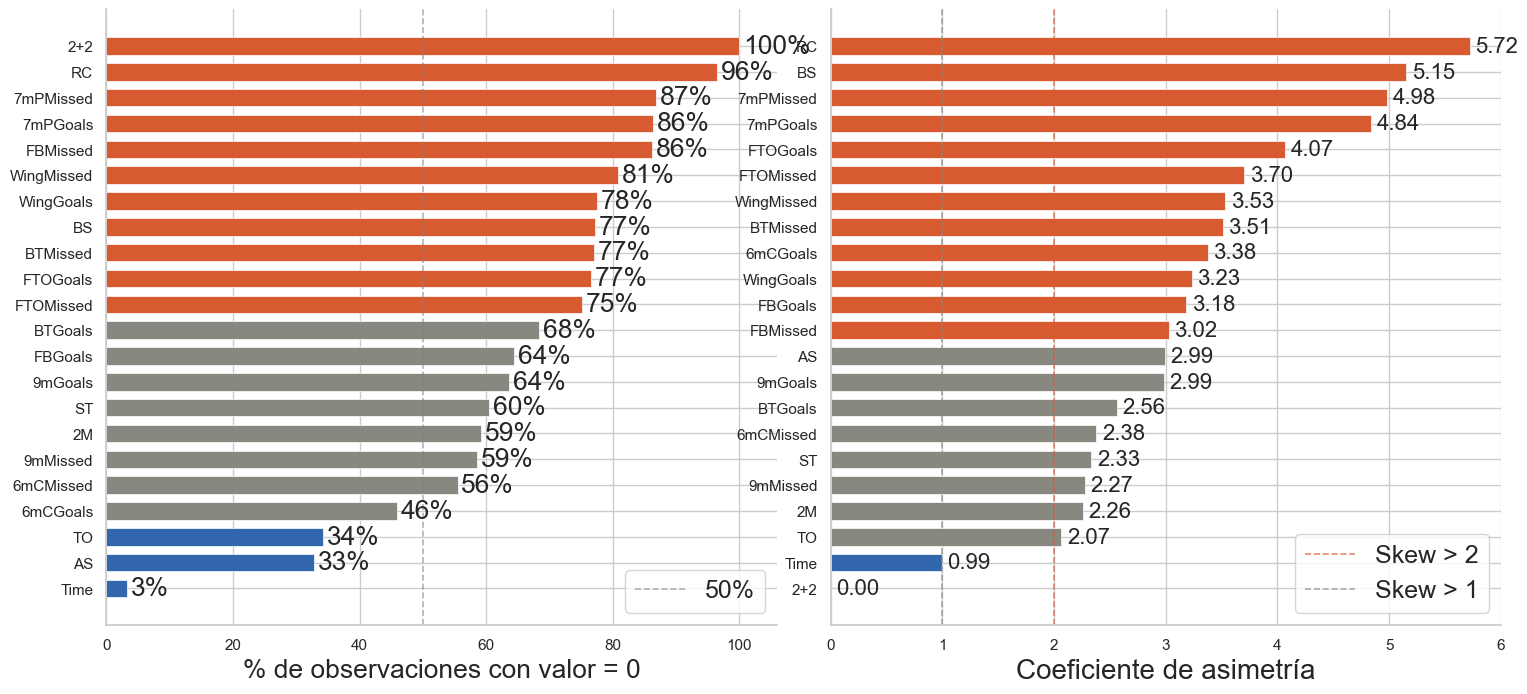

Guardado: eda_output/eda_06_ceros_asimetria.png


In [346]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')
fig.subplots_adjust(wspace=0.08)

ax = axes[0]
sorted_zeros = zeros_pct.sort_values(ascending=True)
colors_z = ['#d85a30' if v > 70 else '#3266ad' if v < 40 else '#888780'
            for v in sorted_zeros.values]
bars = ax.barh(sorted_zeros.index, sorted_zeros.values,
               color=colors_z, edgecolor='white', linewidth=0.5, height=0.68)
ax.axvline(50, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='50%')
for bar, val in zip(bars, sorted_zeros.values):
    ax.text(val + 0.6, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=19)
ax.set_xlabel('% de observaciones con valor = 0', fontsize=19)
ax.tick_params(labelsize=11)
ax.legend(fontsize=18)
ax.set_xlim(0, 106)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
sorted_skew = skewness.sort_values(ascending=True)
colors_s = ['#d85a30' if v > 3 else '#3266ad' if v < 2 else '#888780'
            for v in sorted_skew.values]
bars2 = ax2.barh(sorted_skew.index, sorted_skew.values,
                  color=colors_s, edgecolor='white', linewidth=0.5, height=0.68)
ax2.axvline(2, color='#d85a30', linestyle='--', lw=1.2, alpha=0.7, label='Skew > 2')
ax2.axvline(1, color='#888780', linestyle='--', lw=1.2, alpha=0.7, label='Skew > 1')
for bar, val in zip(bars2, sorted_skew.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=16)
ax2.set_xlabel('Coeficiente de asimetría', fontsize=20)
ax2.tick_params(labelsize=11)
ax2.legend(fontsize=18)
ax2.spines[['top','right']].set_visible(False)

plt.savefig('eda_output/eda_06_ceros_asimetria.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_06_ceros_asimetria.png')


---
## 8. Detección de outliers

In [347]:
THRESHOLD_SIGMAS = 3
outlier_summary = []

for col in NUM_COLS:
    thresh = X[col].mean() + THRESHOLD_SIGMAS * X[col].std()
    mask   = X[col] > thresh
    n      = mask.sum()
    if n > 0:
        players = df.loc[mask, ['Name','Position',col]]
        outlier_summary.append({'Variable': col, 'Umbral': round(thresh,2), 'N outliers': n})
        print(f'── {col}  (umbral={thresh:.1f}, n={n}) ──')
        print(players.sort_values(col, ascending=False).to_string(index=False))
        print()

outlier_df = pd.DataFrame(outlier_summary)

── 7mPGoals  (umbral=9.4, n=12) ──
                          Name Position  7mPGoals
                 Mikkel Hansen       LB        26
              Rutger ten Velde       LW        21
                  Hampus Wanne       LW        20
                    Juri Knorr       CB        14
Alexandre Christoffersen Blonz       LW        13
                  Robert Weber       RW        13
                   Hugo Descat       LW        13
                Mario Sostaric       RW        11
                 Hans Lindberg       RW        11
                 Pedro Portela       RW        11
                  Lucas Pellas       LW        11
            Viggó Kristjánsson       RB        10

── 7mPMissed  (umbral=3.2, n=6) ──
               Name Position  7mPMissed
        Hugo Descat       LW          9
       Hampus Wanne       LW          7
Ómar Ingi Magnusson       RB          7
         Máté Lékai       CB          6
         Juri Knorr       CB          5
         Aleks Vlah       CB          4

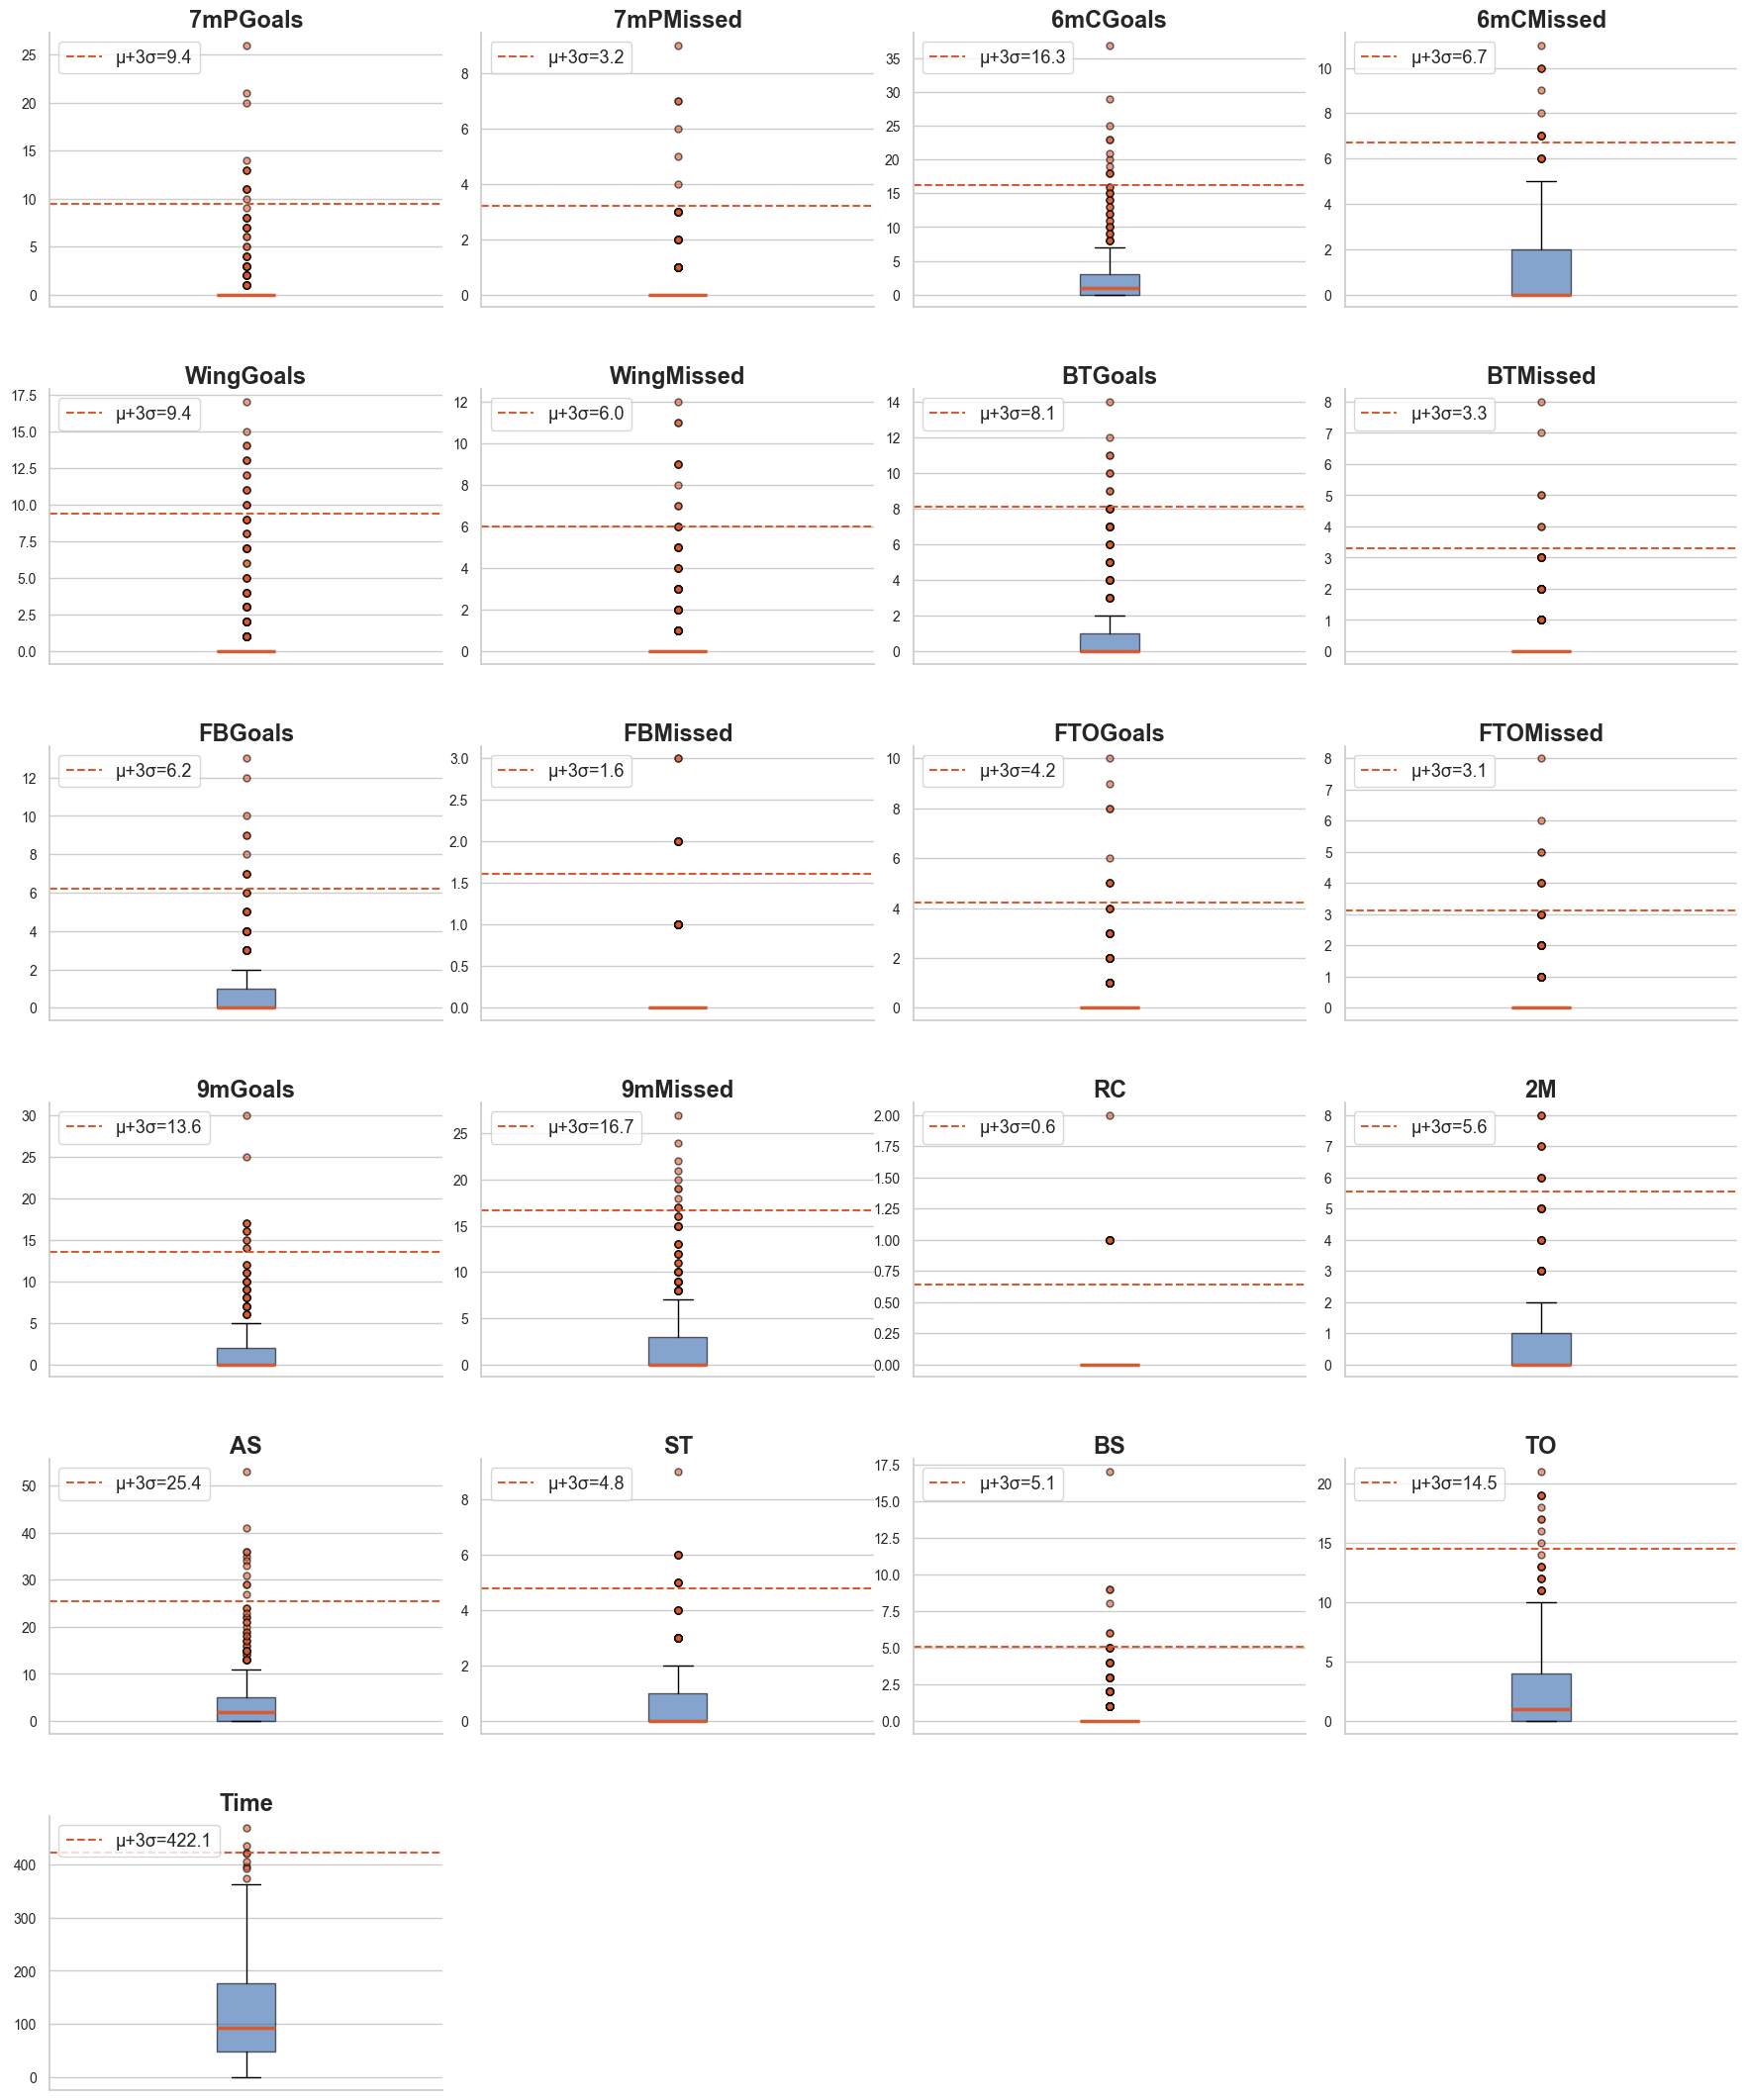

Guardado: eda_output/eda_07_boxplots_outliers.png


In [348]:
vars_with_outliers = outlier_df['Variable'].tolist()
n_cols_plot = 4
n_rows_plot = -(-len(vars_with_outliers) // n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(22, n_rows_plot * 4.5),
                          facecolor='white')
fig.subplots_adjust(hspace=0.30, wspace=0.10)
axes = axes.flatten()

for i, col in enumerate(vars_with_outliers):
    ax = axes[i]
    thresh = X[col].mean() + THRESHOLD_SIGMAS * X[col].std()
    ax.boxplot(X[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3266ad', alpha=0.6),
               medianprops=dict(color='#d85a30', lw=2.5),
               flierprops=dict(marker='o', markerfacecolor='#d85a30',
                               markersize=5, alpha=0.6))
    ax.axhline(thresh, color='#d85a30', linestyle='--', lw=1.5,
               label=f'μ+3σ={thresh:.1f}')
    ax.set_title(col, fontsize=17, fontweight='bold', pad=4)
    ax.legend(fontsize=13, loc='upper left')
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=10)
    ax.spines[['top','right']].set_visible(False)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.savefig('eda_output/eda_07_boxplots_outliers.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_07_boxplots_outliers.png')


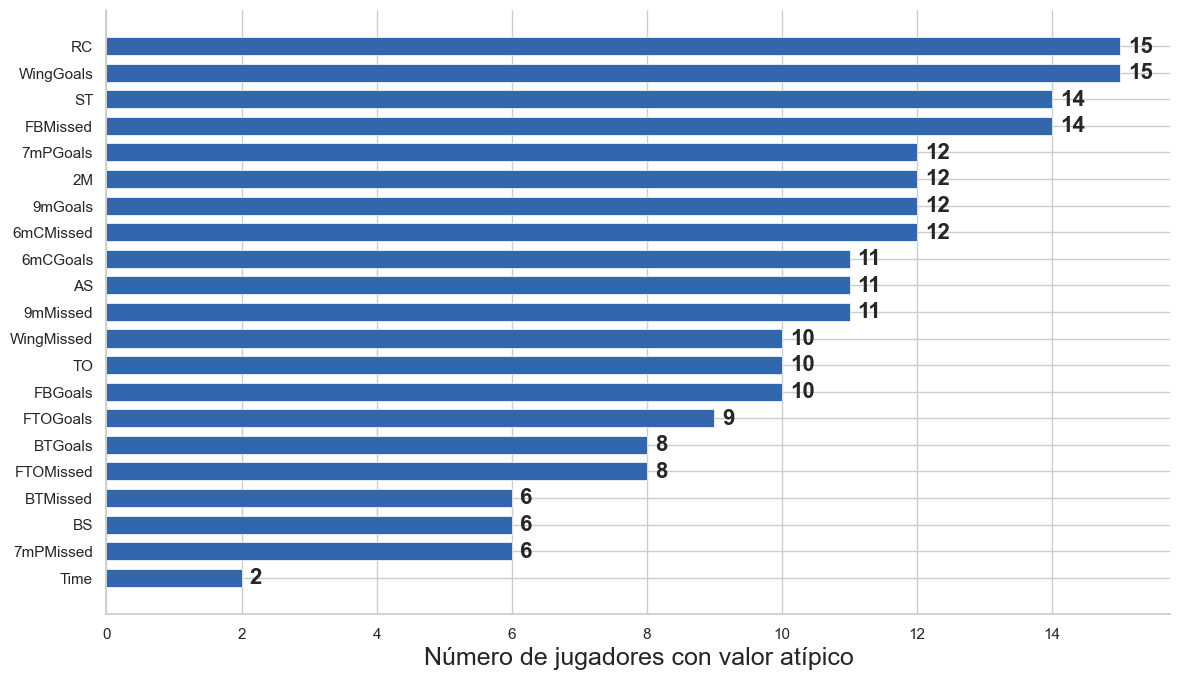

Guardado: eda_output/eda_08_outliers_conteo.png


In [349]:
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
outlier_plot = outlier_df.sort_values('N outliers', ascending=True)
bars = ax.barh(outlier_plot['Variable'], outlier_plot['N outliers'],
               color='#3266ad', edgecolor='white', linewidth=0.5, height=0.68)
for bar, val in zip(bars, outlier_plot['N outliers']):
    ax.text(val + 0.12, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=16, fontweight='bold')
ax.set_xlabel('Número de jugadores con valor atípico', fontsize=18)
ax.tick_params(labelsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_output/eda_08_outliers_conteo.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_08_outliers_conteo.png')


---
## 9. Histogramas individuales

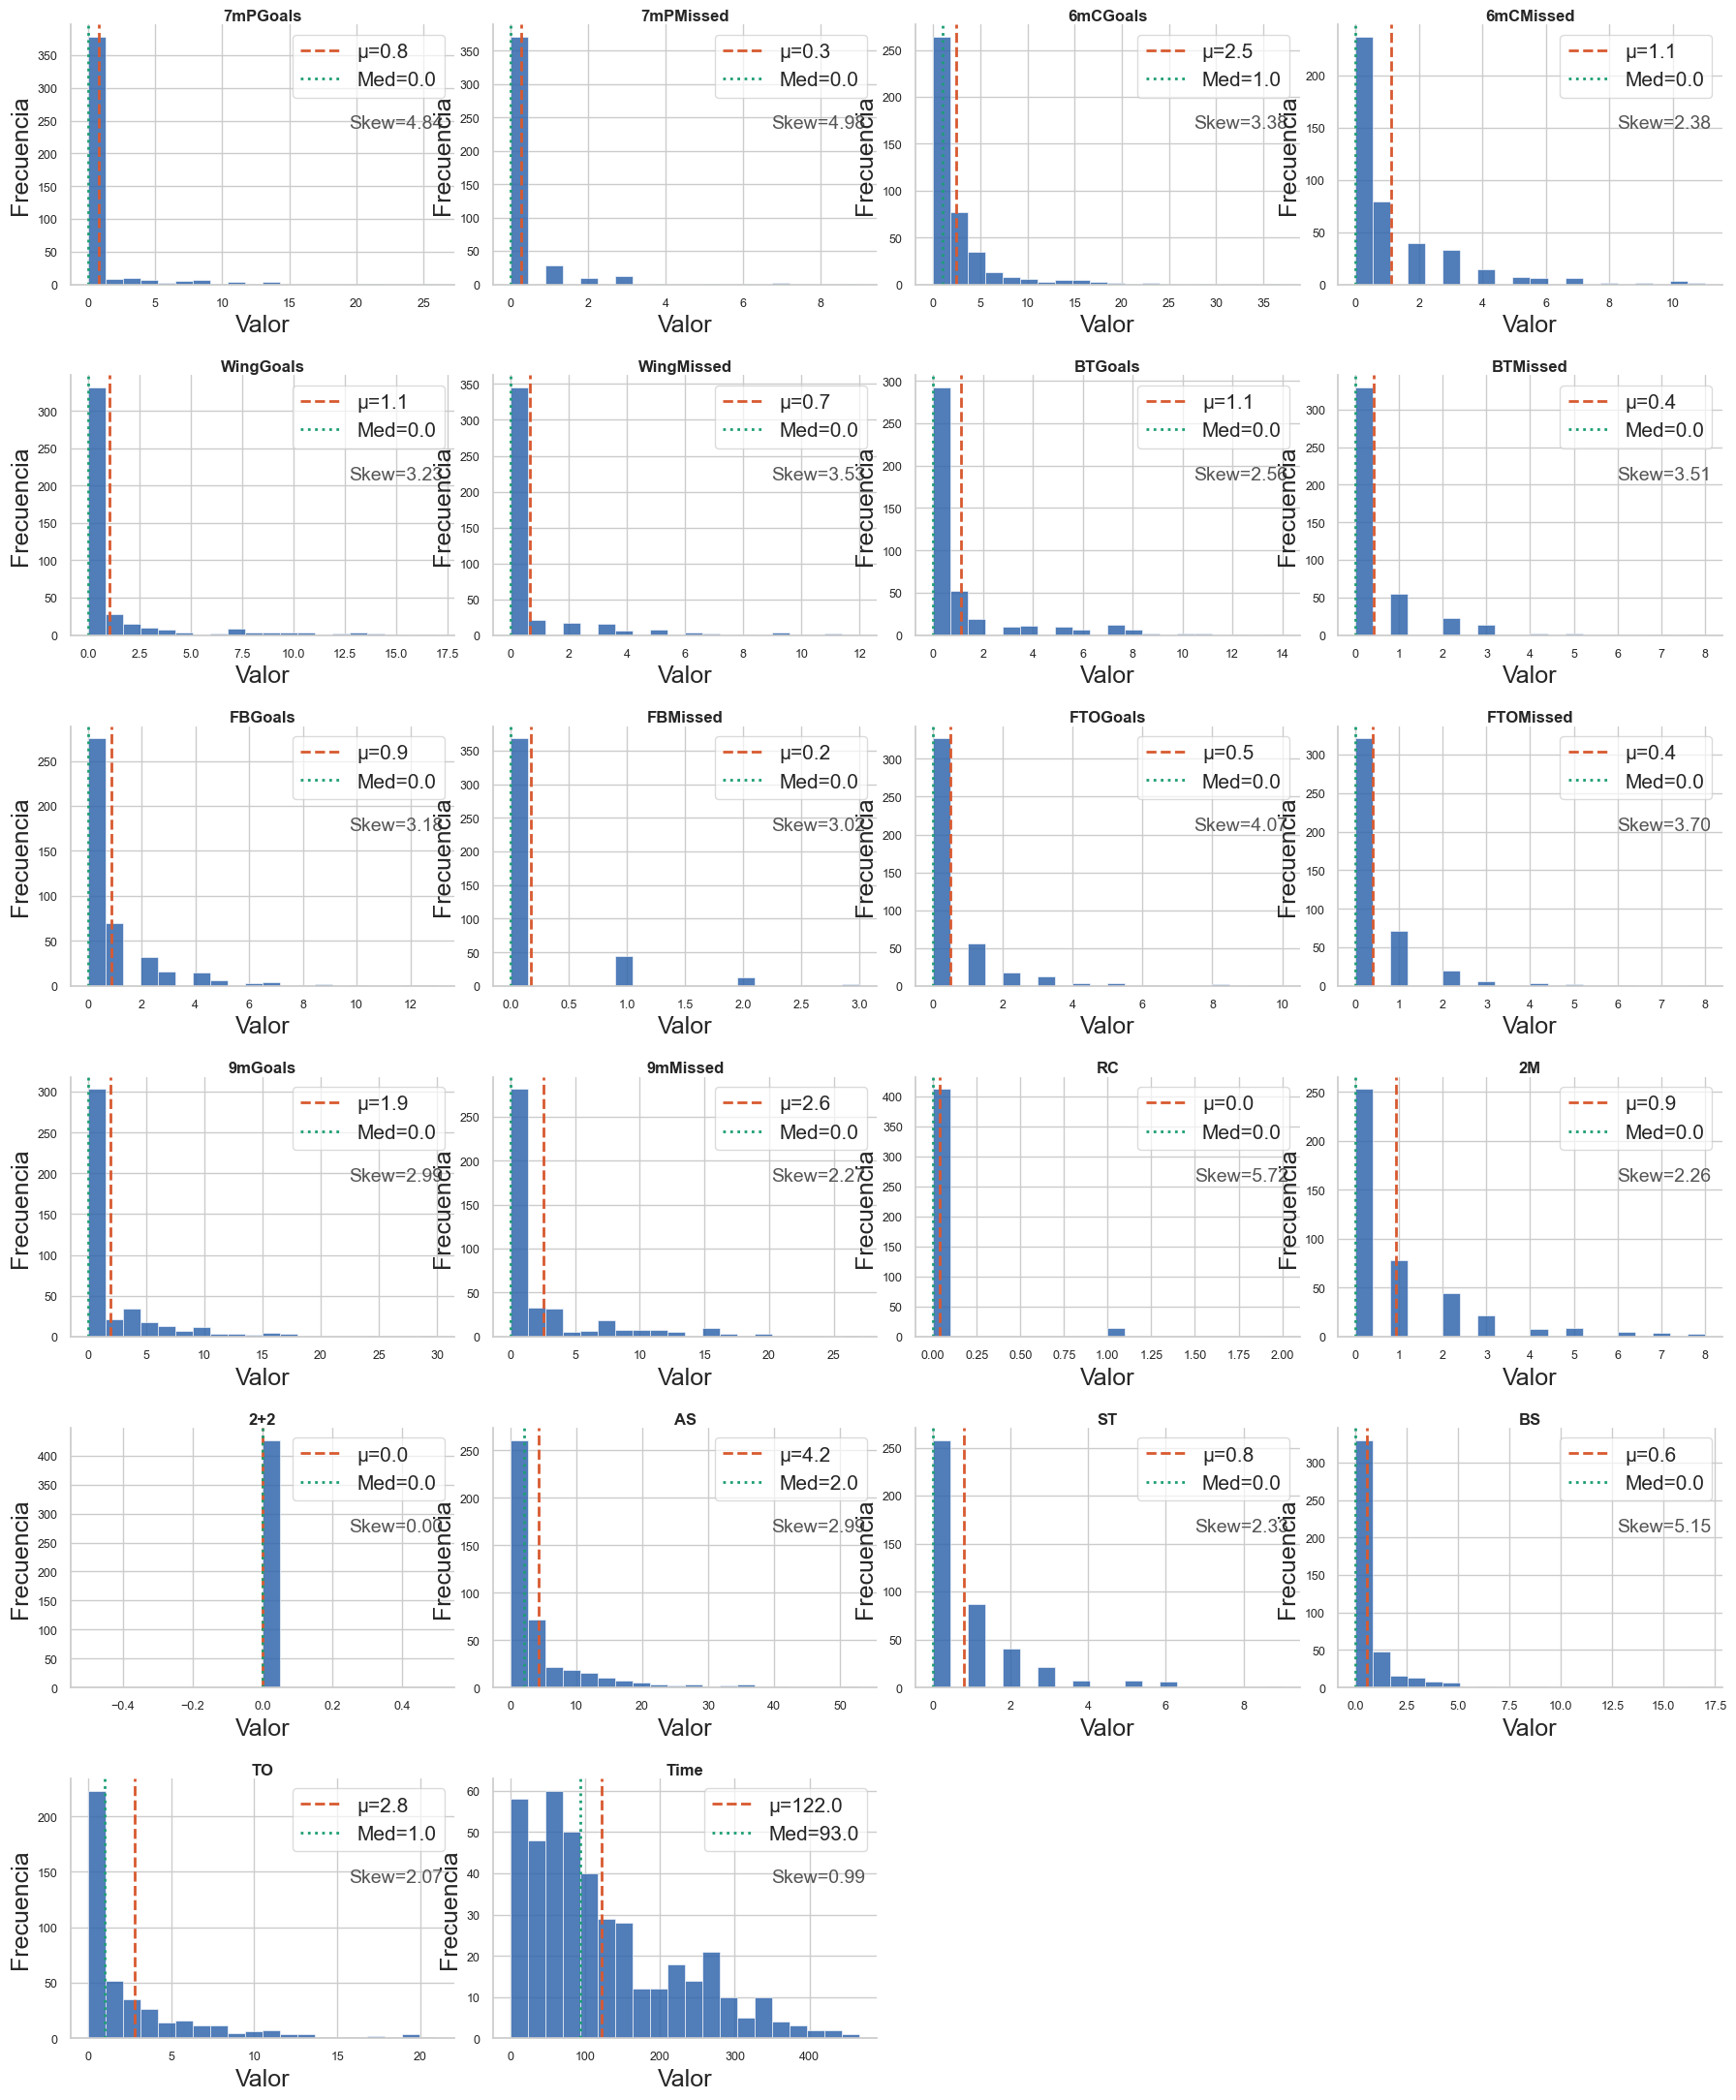

Guardado: eda_output/eda_09_histogramas.png


In [350]:
n_cols_plot = 4
n_rows_plot = -(-len(NUM_COLS) // n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(22, n_rows_plot * 4.5),
                          facecolor='white')
fig.subplots_adjust(hspace=0.35, wspace=0.10)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.hist(X[col].dropna(), bins=20, color='#3266ad',
            edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(X[col].mean(),   color='#d85a30', lw=2, linestyle='--',
               label=f'μ={X[col].mean():.1f}')
    ax.axvline(X[col].median(), color='#1d9e75', lw=2, linestyle=':',
               label=f'Med={X[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold', pad=3)
    ax.legend(fontsize=15, loc='upper right', framealpha=0.7)
    ax.set_xlabel('Valor', fontsize=18)
    ax.set_ylabel('Frecuencia', fontsize=18)
    sk = X[col].skew()
    ax.text(0.97, 0.60, f'Skew={sk:.2f}', transform=ax.transAxes,
            ha='right', fontsize=14, color='#555')
    ax.tick_params(labelsize=9)
    ax.spines[['top','right']].set_visible(False)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.savefig('eda_output/eda_09_histogramas.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_09_histogramas.png')


---
## 10. Violin plots por posición

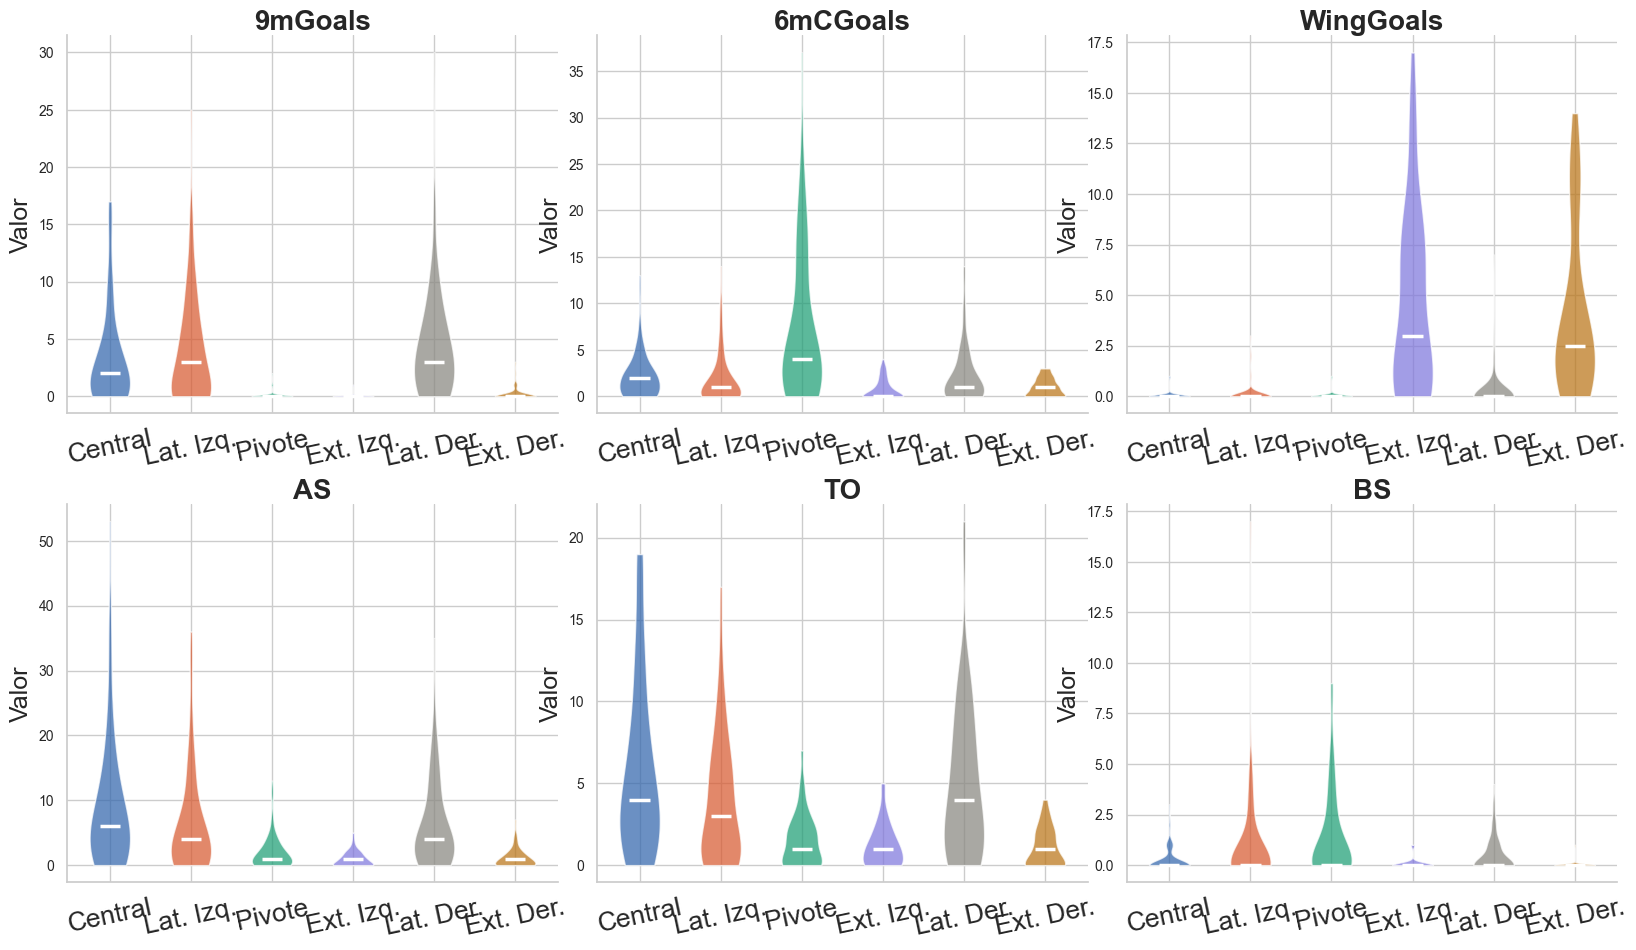

Guardado: eda_output/eda_10_violins_posicion.png


In [351]:
DISC_VARS = ['9mGoals', '6mCGoals', 'WingGoals', 'AS', 'TO', 'BS']
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='white')
fig.subplots_adjust(hspace=0.24, wspace=0.08)
axes = axes.flatten()
pos_labels = [POS_NAMES[p] for p in pos_order]

for i, col in enumerate(DISC_VARS):
    ax = axes[i]
    data_plot = [df.loc[df['Position'] == pos, col].values for pos in pos_order]
    parts = ax.violinplot(data_plot, positions=range(len(pos_order)),
                           showmedians=True, showextrema=False)
    for pi, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(POS_COLORS.values())[pi])
        pc.set_alpha(0.72)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2.5)
    ax.set_xticks(range(len(pos_order)))
    ax.set_xticklabels(pos_labels, rotation=12, fontsize=19)
    ax.set_title(col, fontsize=20, fontweight='bold', pad=4)
    ax.set_ylabel('Valor', fontsize=18)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.savefig('eda_output/eda_10_violins_posicion.png', dpi=180, bbox_inches='tight')
plt.show()
print('Guardado: eda_output/eda_10_violins_posicion.png')


---
## 11. Resumen ejecutivo

In [352]:
print('=' * 55)
print('RESUMEN EDA — EHF 2024 MASCULINO')
print('=' * 55)
print(f'Jugadores de campo (sin GK) : {len(df)}')
print(f'Variables de clustering     : {len(NUM_COLS)}')
print(f'Valores nulos               : {X.isnull().sum().sum()}')
print()
print('Posición más representada    :', df["Position"].value_counts().idxmax(),
      f'({df["Position"].value_counts().max()} jugadores)')
print('Posición menos representada  :', df["Position"].value_counts().idxmin(),
      f'({df["Position"].value_counts().min()} jugadores)')
print()
print(f'Variables con >70% ceros    : {(zeros_pct > 70).sum()}')
print(f'Variables con skewness >3   : {(skewness > 3).sum()}')
print(f'Variables con outliers (μ+3σ): {len(outlier_df)}')
print()
print('Pares con |r| > 0.7:')
for a, b, r in pairs:
    print(f'  {a} — {b}: {r}')
print()
print('Figuras generadas en eda_output/:')
for f in sorted(os.listdir('eda_output')):
    print(f'  {f}')

RESUMEN EDA — EHF 2024 MASCULINO
Jugadores de campo (sin GK) : 427
Variables de clustering     : 22
Valores nulos               : 0

Posición más representada    : LB (83 jugadores)
Posición menos representada  : LW (46 jugadores)

Variables con >70% ceros    : 11
Variables con skewness >3   : 12
Variables con outliers (μ+3σ): 21

Pares con |r| > 0.7:
  9mGoals — 9mMissed: 0.856
  AS — TO: 0.845
  WingGoals — WingMissed: 0.822
  BTGoals — AS: 0.779
  BTGoals — TO: 0.741
  6mCGoals — 6mCMissed: 0.724
  9mMissed — AS: 0.716
  7mPGoals — 7mPMissed: 0.712

Figuras generadas en eda_output/:
  eda_01_distribucion_posicion.png
  eda_02_stats_global.png
  eda_03_stats_posicion.png
  eda_04_correlacion.png
  eda_06_ceros_asimetria.png
  eda_07_boxplots_outliers.png
  eda_08_outliers_conteo.png
  eda_09_histogramas.png
  eda_10_violins_posicion.png
